In [1]:
# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU Available: True
Using device: cuda


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False, num_workers=2)

In [17]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=0.01)  # better init
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Start negative → sigmoid ≈ 0.27, so gates begin mostly closed
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), -1.0)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)       # (0, 1)
        pruned_weights = self.weight * gates           # element-wise mask
        return F.linear(x, pruned_weights, self.bias)


In [18]:
class PrunableNet(nn.Module):
    """
    Conv layers handle spatial features (not pruned here for simplicity).
    PrunableLinear layers are applied in the classifier head.
    """
    def __init__(self):
        super().__init__()
        # Fixed CNN backbone
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 16×16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 8×8

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),   # → 4×4
        )
        # Prunable classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            PrunableLinear(256 * 4 * 4, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            PrunableLinear(1024, 512),
            nn.ReLU(),
            PrunableLinear(512, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x

In [19]:
def sparsity_loss(model):
    """Raw L1 sum of all gate values (not normalized)."""
    total = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.sum()
    return total


In [20]:
def train_model(lambda_val=1e-4, epochs=30):
    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    # Reduce LR when loss plateaus
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            cls_loss = criterion(outputs, labels)
            sp_loss  = sparsity_loss(model)
            loss     = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}  Loss: {total_loss:.4f}"
                  f"  LR: {scheduler.get_last_lr()[0]:.6f}")

    return model

In [21]:
def evaluate_model(model, threshold=1e-2):
    model.eval()
    correct = total = 0
    all_gates = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    all_gates = np.array(all_gates)
    sparsity  = np.mean(all_gates < threshold) * 100
    accuracy  = 100 * correct / total
    return accuracy, sparsity, all_gates


Training with lambda = 1e-06
Epoch   5/30  Loss: 1161.1099  LR: 0.000933
Epoch  10/30  Loss: 1108.0024  LR: 0.000750
Epoch  15/30  Loss: 1062.5482  LR: 0.000500
Epoch  20/30  Loss: 1026.9841  LR: 0.000250
Epoch  25/30  Loss: 1000.5785  LR: 0.000067
Epoch  30/30  Loss: 990.2613  LR: 0.000000
  Test Accuracy : 90.07%
  Sparsity Level: 0.00%


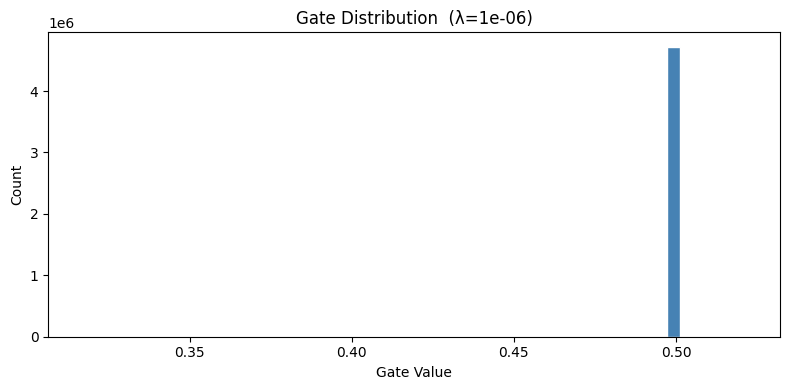


Training with lambda = 1e-05
Epoch   5/30  Loss: 9184.1299  LR: 0.000933
Epoch  10/30  Loss: 9306.8329  LR: 0.000750
Epoch  15/30  Loss: 9260.4876  LR: 0.000500
Epoch  20/30  Loss: 9224.8078  LR: 0.000250
Epoch  25/30  Loss: 9198.8508  LR: 0.000067
Epoch  30/30  Loss: 9189.0885  LR: 0.000000
  Test Accuracy : 90.48%
  Sparsity Level: 0.00%


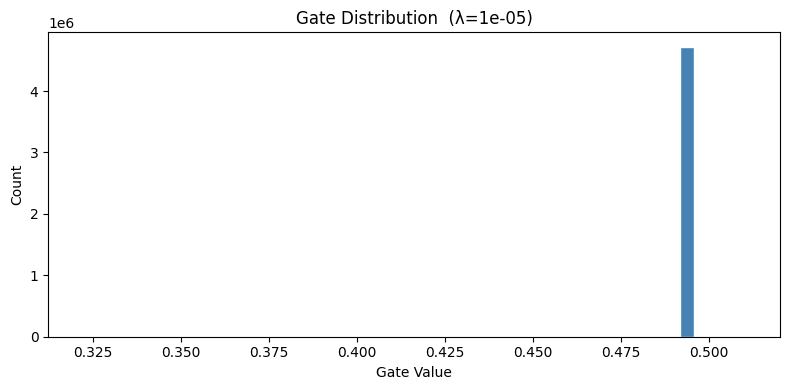


Training with lambda = 0.0001
Epoch   5/30  Loss: 80902.4834  LR: 0.000933
Epoch  10/30  Loss: 81218.1073  LR: 0.000750
Epoch  15/30  Loss: 81175.2546  LR: 0.000500
Epoch  20/30  Loss: 81140.1632  LR: 0.000250
Epoch  25/30  Loss: 81116.7497  LR: 0.000067
Epoch  30/30  Loss: 81106.3255  LR: 0.000000
  Test Accuracy : 90.27%
  Sparsity Level: 0.00%


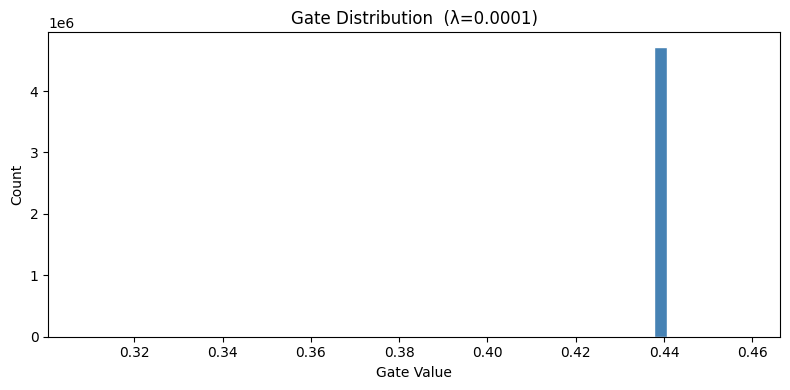

In [22]:
lambdas = [1e-6, 1e-5, 1e-4]   # tune based on your sparsity goals
results = []

for lam in lambdas:
    print(f"\n{'='*50}")
    print(f"Training with lambda = {lam}")
    model = train_model(lambda_val=lam, epochs=30)

    acc, sparsity, gates = evaluate_model(model)
    results.append((lam, acc, sparsity))
    print(f"  Test Accuracy : {acc:.2f}%")
    print(f"  Sparsity Level: {sparsity:.2f}%")

    plt.figure(figsize=(8, 4))
    plt.hist(gates, bins=50, color='steelblue', edgecolor='white')
    plt.title(f"Gate Distribution  (λ={lam})")
    plt.xlabel("Gate Value"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()


In [23]:
print("\n" + "="*45)
print(f"{'Lambda':<12} {'Accuracy (%)':>14} {'Sparsity (%)':>14}")
print("-"*45)
for lam, acc, sp in results:
    print(f"{lam:<12} {acc:>14.2f} {sp:>14.2f}")


Lambda         Accuracy (%)   Sparsity (%)
---------------------------------------------
1e-06                 90.07           0.00
1e-05                 90.48           0.00
0.0001                90.27           0.00
